<a href="https://colab.research.google.com/github/jaewoo0108/ml-journey/blob/main/week02-gradient-descent/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2 : 비용 함수와 경사하강법

## 이번주 핵심
- **비용 함수 (Cost Function)**: 모델이 얼마나 틀리는지 측정하는 함수
- **경사하강법( Gradient Descent)**: 비용을 줄이는 방향으로 파라미터들을 업데이트하는 알고리즘
- **학습률 (Alpha, α)** : 한번에 얼마나 움직일 결정하는 하이퍼 파라미터 (0~1)

## 핵심공식
- 모델 : f(x) = wx + b
- 비용 함수 : J(w,b) =  
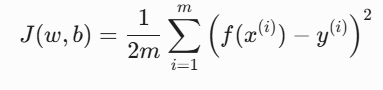
- 업데이트 (반복) :



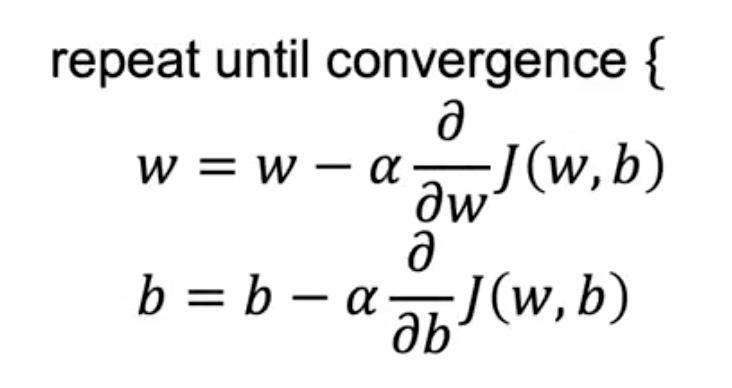

**중요**:  w와 b는 **동시에** 업데이트되어야한다 (같은 시점의 기울기로 계산)


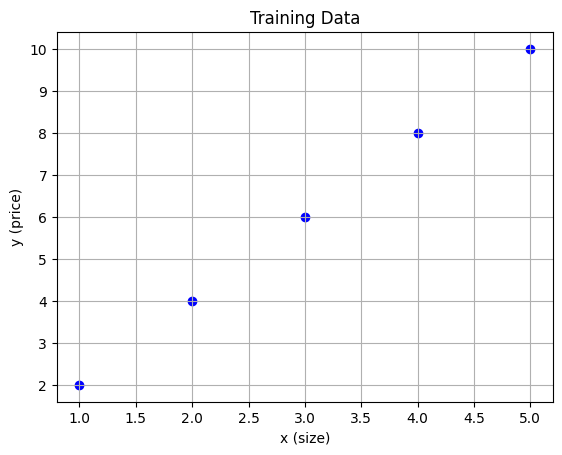

데이터 개수 m = 5


In [ ]:
# 선형회귀 사상 데이터 만들기 (y= 2x)

import numpy as np
import matplotlib.pyplot as plt

# 집 크기 -> 가상 가격 데이터( 정답은 y = 2x, w= 2, b = 0)
x = np.array([1, 2, 3, 4, 5])  # 입력값 (크기)
y = np.array([2, 4, 6, 8, 10])  # 실제 정답 (가격)

# 점으로 찍어서 그래프 표시
plt.scatter(x, y, color = 'blue')
plt.xlabel("x (size)")
plt.ylabel("y (price)")
plt.title("Training Data")
plt.grid(True)
plt.show()

print(f"데이터 개수 m = {len(x)}")

In [ ]:
# 제곱오차 비용 함수를 직접 완성

def compute_cost( x, y, w, b):
  """
  J(w,b) = (1/m) * Σ (f(x) - y)^2
  """
  m = len(x)  # 데이터 개수
  total_cost = 0  # 오차 누적용 변수

  for i in range(m):
    f_wb = w * x[i] + b
    cost_i = (f_wb - y[i]) ** 2
    total_cost = total_cost + cost_i

  total_cost = total_cost / (m)
  return total_cost

# 여러 파라미터 (w, b)로 테스트해서 비용 비교
print(f"w = 0, b = 0 -> 비용 : {compute_cost(x,y,0,0):.4f}")
print(f"w = 1.5, b = 0 -> 비용 : {compute_cost(x,y,1.5,0):.4f}")
print(f"w = 2 , b = 0 -> 비용 : {compute_cost(x,y,2,0):.4f}")


w = 0, b = 0 -> 비용 : 44.0000
w = 1.5, b = 0 -> 비용 : 2.7500
w = 2 , b = 0 -> 비용 : 0.0000


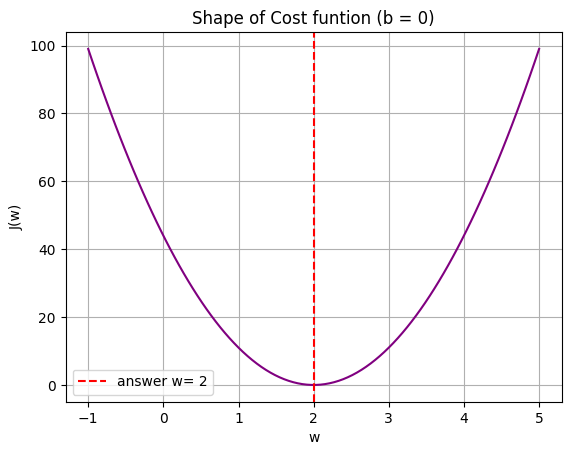

In [ ]:
# w를 바꿔가며 비용이 어떻게 변하는지 그려보기

# w -1 ~ 5 까지 변경 (b는 고정)
w_values = np.linspace(-1,5,100)
costs = [compute_cost(x,y,w,b = 0) for w in w_values]

plt.plot(w_values, costs, color = 'purple')
plt.axvline(x = 2, color = 'red', linestyle = '--', label = 'answer w= 2')
plt.xlabel("w")
plt.ylabel("J(w)")
plt.title("Shape of Cost funtion (b = 0)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# 비용 함수의 기울기 구하고 경사하강법으로 최적의 w, b 찾기

def compute_gradient(x, y, w, b):
  """
  J(w,b)의 w, b에 대한 편미분(기울기) 계산
  """
  m = len(x)
  dj_dw = 0
  dj_db = 0
  for i in range(m):
    f_wb = w * x[i] + b
    dj_dw += (f_wb - y[i]) * x[i]
    dj_db += (f_wb - y[i])
  return (2 * dj_dw) / m, (2 * dj_db) / m

# 경사하강법 실행
w, b = 0.0 , 0.0
alpha = 0.01
num_iters = 1000
cost_history = []

for i in range(num_iters):
  dj_dw, dj_db = compute_gradient(x, y, w, b)
  w = w - alpha * dj_dw
  b = b - alpha * dj_db
  cost_history.append(compute_cost(x, y, w, b))

print(f"최종 w : {w:.4f}  (Answer: 2.0)")
print(f"최종 b : {b:.4f}  (Answer : 0.0)")
print(f"최종 비용 : {cost_history[-1]:.6f}")





최종 w : 1.9952  (Answer: 2.0)
최종 b : 0.0174  (Answer : 0.0)
최종 비용 : 0.000055


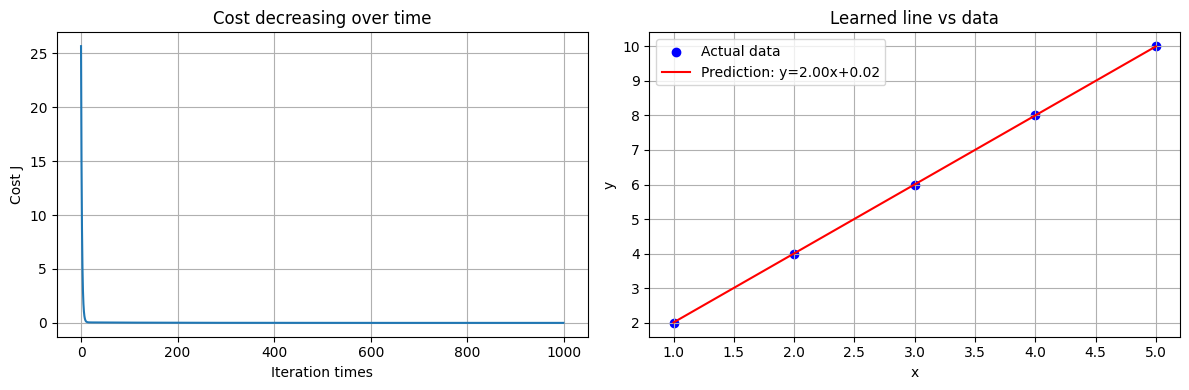

In [ ]:
# 경사하강법의 결과 그림으로 확인

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 왼쪽 그래프 : 비용이 줄어드는 모습
axes[0].plot(cost_history)
axes[0].set_xlabel("Iteration times")
axes[0].set_ylabel("Cost J")
axes[0].set_title("Cost decreasing over time")
axes[0].grid(True)

# 오른쪽 그래프 : 학습된 직선이 데이터를 잘 따라가는지
axes[1].scatter(x, y, color='blue', label='Actual data')
axes[1].plot(x, w * x + b, color='red', label=f'Prediction: y={w:.2f}x+{b:.2f}')
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_title("Learned line vs data")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

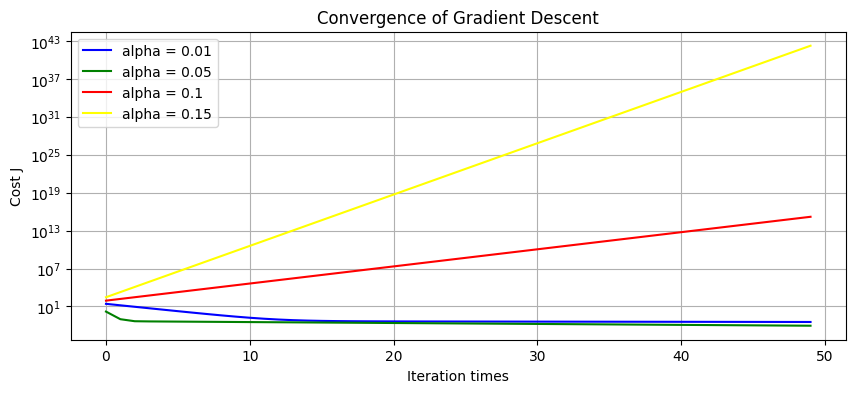

In [ ]:
# 학습률 크기에 따라 수렴 속도/ 발산이 달라지는 형상

alphas = [0.01, 0.05, 0.1, 0.15]
colors = ['blue', 'green', 'red', 'yellow']

plt.figure(figsize=(10,4))

for alpha, color in zip(alphas, colors):
  w, b = 0.0, 0.0
  history = []
  for i in range(50):
    dj_dw, dj_db = compute_gradient(x, y, w, b)
    w = w - alpha * dj_dw
    b = b - alpha * dj_db
    history.append(compute_cost(x, y, w, b))

  plt.plot(history, color = color, label = f"alpha = {alpha}")

plt.xlabel("Iteration times")
plt.ylabel("Cost J")
plt.yscale("log")
plt.title("Convergence of Gradient Descent")
plt.legend()
plt.grid(True)
plt.show()

## 정리

- 학습률이 너무 크면 건너뛴 곳이 시작점보다 더 가파른 곳이라서, 돌아오는 점프가 가는 점프보다 커진다. 그래서 진동하면서 점점 커진다

- sklearn에서 fit은 학습, predict는 학습 끝난 모델에 새 데이터 넣어서 답 받기

In [ ]:
# 도전 과제

# sklearn으로 비교해보기: from sklearn.linear_model import LinearRegression 가져와서 같은 데이터에 fit 시켜보고, 우리가 직접 구한 w, b와 비교

from sklearn.linear_model import LinearRegression

X = x.reshape(-1,1)

sklearn_model = LinearRegression()
sklearn_model.fit(X, y)

w_sk = sklearn_model.coef_[0]
b_sk = sklearn_model.intercept_

print(f"sklearn이 찾은 w = {w_sk:.4f}, b = {b_sk:.4f}")
print(f"그때의 cost = {compute_cost(x, y, w_sk, b_sk):.6f}")

# 내 결과랑 비교

print("\n=== 비교 ===")
print(f"내가 짠 코드:  w = {w:.4f},  b = {b:.4f},  cost = {cost_history[-1]:.6f}")
print(f"sklearn:      w = {w_sk:.4f},  b = {b_sk:.4f},  cost = {compute_cost(x, y, w_sk, b_sk):.6f}")
print(f"정답:         w = 2.0000,  b = 0.0000")

# 학습시키지 않은 데이터로 예측
new_x = np.array([[6], [7], [10]])
predictions = sklearn_model.predict(new_x)

print(f"\n새로운 데이터 입력의 예측값 : {predictions}")

sklearn이 찾은 w = 2.0000, b = 0.0000
그때의 cost = 0.000000

=== 비교 ===
내가 짠 코드:  w = 1.9952,  b = 0.0174,  cost = 0.000055
sklearn:      w = 2.0000,  b = 0.0000,  cost = 0.000000
정답:         w = 2.0000,  b = 0.0000

새로운 데이터 입력의 예측값 : [12. 14. 20.]
